# RQ2 — Divergence of the reached configuration space

How does the space reached by models compare with the one reached by humans?

Two panels:

- **(a)** Reach by cohort. The model reaches about as far as the average human; only the kernel expert reaches noticeably wider. Git flips the order and CI ties.
- **(b)** How the used options split into a shared core, a human-only remainder, and a model-only remainder.

Output: `results/analysis/figures/rq2_divergence.pdf`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# find the results dir by walking up from the notebook
BASE = Path.cwd()
while not (BASE / 'results' / 'analysis').exists() and BASE != BASE.parent:
    BASE = BASE.parent
AN  = BASE / 'results' / 'analysis'
FIG = AN / 'figures'; FIG.mkdir(exist_ok=True)
def load(name): return pd.read_csv(AN / name)

# same plot style as the RQ1 figure
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12.5,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 12, 'axes.labelcolor': '#222222',
    'axes.edgecolor': '#9aa0a6', 'axes.linewidth': 0.9,
    'xtick.color': '#3c4043', 'ytick.color': '#3c4043',
    'xtick.labelsize': 11.5, 'ytick.labelsize': 11.5,
    'text.color': '#202124',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130, 'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})

# Okabe-Ito colours
C      = {'human': '#0072B2', 'llm': '#D55E00', 'kernel': '#009E73'}
SHARED = '#6b7280'   # options reached by both cohorts
TRACK  = '#eef1f5'
DS   = ['gnu', 'git', 'ci']
DSL  = {'gnu': 'GNU utilities', 'git': 'Git', 'ci': 'CI tooling'}
LAB  = {'kernel': 'expert', 'human': 'human', 'llm': 'model'}
print('results dir:', AN)

results dir: /home/ternava/Documents/GitHub/llms-miss/results/analysis


In [2]:
# reach and option count per cohort
cov = load('a1_population_coverage.csv')
inv = load('invocations_long.csv')
gt  = load('groundtruth_long.csv')

reach = {(r.dataset, r.population): r.reach_pct for r in cov.itertuples()}
nopt  = {(r.dataset, r.population): int(r.opts_used) for r in cov.itertuples()}

# split the valid used (unit, option) pairs into shared, human-only, model-only
used = inv[inv.option.notna() & (inv.option != '')].merge(gt, on=['dataset', 'unit', 'option'])
part = {}
for d in DS:
    sub = used[used.dataset == d]
    H = set(zip(sub[sub.population == 'human'].unit, sub[sub.population == 'human'].option))
    M = set(zip(sub[sub.population == 'llm'].unit,   sub[sub.population == 'llm'].option))
    part[d] = {'human_only': len(H - M), 'shared': len(H & M), 'model_only': len(M - H)}
part

{'gnu': {'human_only': 58, 'shared': 88, 'model_only': 60},
 'git': {'human_only': 38, 'shared': 59, 'model_only': 78},
 'ci': {'human_only': 32, 'shared': 7, 'model_only': 23}}

wrote /home/ternava/Documents/GitHub/llms-miss/results/analysis/figures/rq2_reach.pdf


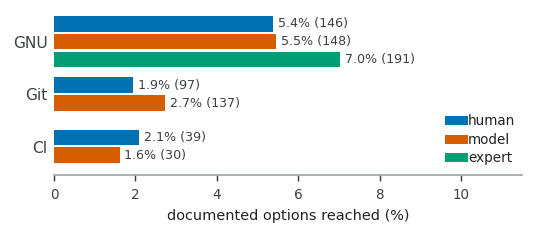

wrote /home/ternava/Documents/GitHub/llms-miss/results/analysis/figures/rq2_partition.pdf


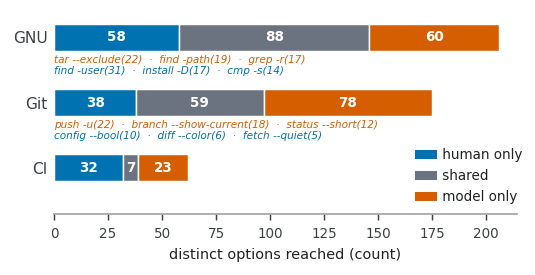

In [3]:
DSS = {'gnu': 'GNU', 'git': 'Git', 'ci': 'CI'}
cohortsA = {'gnu': ['human', 'llm', 'kernel'], 'git': ['human', 'llm'], 'ci': ['human', 'llm']}

# panel (a): reach by cohort
figA, axA = plt.subplots(figsize=(4, 1.7))
figA.set_constrained_layout(True)
BW = 0.34
yb = np.arange(len(DS))[::-1].astype(float)
for i, d in enumerate(DS):
    coh = cohortsA[d]
    offs = (np.arange(len(coh)) - (len(coh) - 1) / 2) * BW
    for p, off in zip(coh, offs):
        r = reach[(d, p)]
        axA.barh(yb[i] - off, r, height=BW * 0.88, color=C[p], edgecolor='none', zorder=2)
        axA.text(r + 0.12, yb[i] - off, f"{r:.1f}% ({nopt[(d, p)]})",
                 va='center', ha='left', fontsize=7, color='#3c4043', zorder=3)
axA.set_yticks(yb); axA.set_yticklabels([DSS[d] for d in DS], fontsize=8.5)
axA.set_ylim(yb.min() - 0.55, yb.max() + 0.55)
axA.set_xlim(0, 11.5)
axA.set_xlabel('documented options reached (%)', fontsize=8)
axA.tick_params(axis='x', labelsize=7.5); axA.tick_params(axis='y', length=0)
axA.spines['left'].set_visible(False)
axA.legend(handles=[Line2D([0], [0], color=C[k], lw=5, label=LAB[k]) for k in ('human', 'llm', 'kernel')],
           frameon=False, fontsize=7.5, loc='lower right', bbox_to_anchor=(1.0, 0.02), ncol=1,
           handlelength=1.0, handletextpad=0.4, labelspacing=0.35, borderpad=0.0)
figA.savefig(FIG / 'rq2_reach.pdf')
print('wrote', FIG / 'rq2_reach.pdf')
plt.show()

# panel (b): shared core vs exclusive options, with the top exclusive options named
model_top = {
    'gnu': 'tar --exclude(22)  ·  find -path(19)  ·  grep -r(17)',
    'git': 'push -u(22)  ·  branch --show-current(18)  ·  status --short(12)',
}
human_top = {
    'gnu': 'find -user(31)  ·  install -D(17)  ·  cmp -s(14)',
    'git': 'config --bool(10)  ·  diff --color(6)  ·  fetch --quiet(5)',
}
figB, axB = plt.subplots(figsize=(4, 2))
figB.set_constrained_layout(True)
yB = np.arange(len(DS))[::-1].astype(float) * 1.2   # wider spacing to fit the labels
xmax = max(sum(part[d].values()) for d in DS)
for yi, d in zip(yB, DS):
    h, s, m = part[d]['human_only'], part[d]['shared'], part[d]['model_only']
    segs = [('human', h, C['human']), ('shared', s, SHARED), ('llm', m, C['llm'])]
    left = 0
    for name, w, col in segs:
        axB.barh(yi, w, left=left, height=0.5, color=col, edgecolor='white', linewidth=0.8, zorder=2)
        axB.text(left + w / 2, yi, f"{w}", va='center', ha='center',
                 fontsize=7.5, color='white', fontweight='bold', zorder=3)
        left += w
    if d in model_top:
        axB.text(0, yi - 0.32, model_top[d], va='top', ha='left',
                 fontsize=5.8, color=C['llm'], style='italic', zorder=4)
    if d in human_top:
        axB.text(0, yi - 0.52, human_top[d], va='top', ha='left',
                 fontsize=5.8, color=C['human'], style='italic', zorder=4)
axB.set_yticks(yB); axB.set_yticklabels([DSS[d] for d in DS], fontsize=8.5)
axB.set_ylim(yB.min() - 0.85, yB.max() + 0.45)
axB.set_xlim(0, xmax * 1.04)
axB.set_xlabel('distinct options reached (count)', fontsize=8)
axB.tick_params(axis='x', labelsize=7.5); axB.tick_params(axis='y', length=0)
axB.spines['left'].set_visible(False)
axB.legend(handles=[Line2D([0], [0], color=C['human'], lw=5, label=' human only'),
                    Line2D([0], [0], color=SHARED, lw=5, label=' shared'),
                    Line2D([0], [0], color=C['llm'], lw=5, label=' model only')],
           frameon=False, fontsize=7.5, loc='lower center', bbox_to_anchor=(0.9, 0.02), ncol=1,
           handlelength=1.0, handletextpad=0.4, columnspacing=1.0, borderpad=0.0)
figB.savefig(FIG / 'rq2_partition.pdf')
print('wrote', FIG / 'rq2_partition.pdf')
plt.show()